**Assignment 6** - Decision Tree

Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

print("Libraries imported")

Libraries imported


Load dataset

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

dataset = pd.DataFrame(X, columns=iris.feature_names)
dataset['Species'] = y

dataset.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


Dataset summary

In [3]:
print("Shape:", dataset.shape)
print("\nColumns:", dataset.columns.tolist())

print("\nClass Distribution:")
print(dataset['Species'].value_counts())

Shape: (150, 5)

Columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'Species']

Class Distribution:
Species
0    50
1    50
2    50
Name: count, dtype: int64


Separate features and target

In [4]:
X = dataset.drop('Species', axis=1)
y = dataset['Species']

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Train test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (105, 4)
Testing size: (45, 4)


Build decision tree

In [6]:
dt = DecisionTreeClassifier(criterion='entropy', random_state=1)

dt.fit(X_train, y_train)

print("Decision Tree model trained")

Decision Tree model trained


Visualise

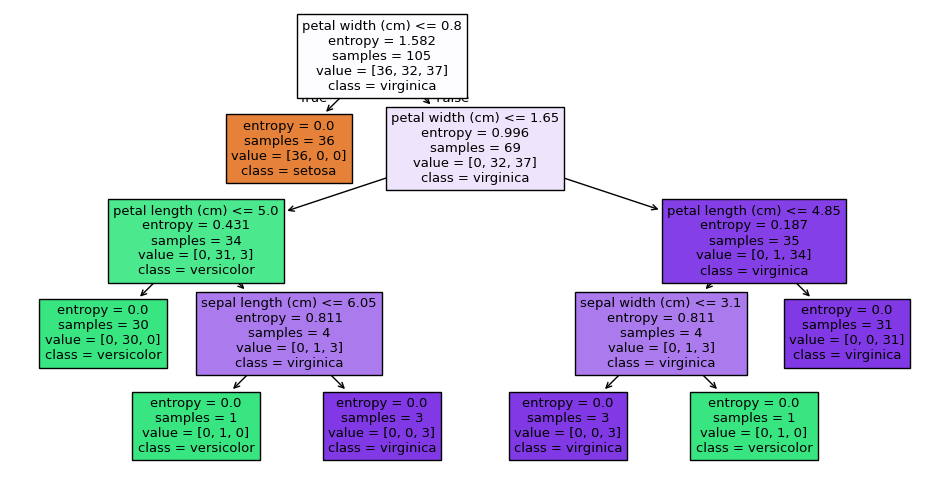

In [7]:
plt.figure(figsize=(12,6))

plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

Predict and evaluate

In [8]:
y_pred = dt.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results["Status"] = results.apply(
    lambda r: "Correct" if r.Actual == r.Predicted else "Wrong",
    axis=1
)

print(results)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

     Actual  Predicted   Status
14        0          0  Correct
98        1          1  Correct
75        1          1  Correct
16        0          0  Correct
131       2          2  Correct
56        1          1  Correct
141       2          2  Correct
44        0          0  Correct
29        0          0  Correct
120       2          2  Correct
94        1          1  Correct
5         0          0  Correct
102       2          2  Correct
51        1          1  Correct
78        1          1  Correct
42        0          0  Correct
92        1          1  Correct
66        1          1  Correct
31        0          0  Correct
35        0          0  Correct
90        1          1  Correct
84        1          1  Correct
77        1          2    Wrong
40        0          0  Correct
125       2          2  Correct
99        1          1  Correct
33        0          0  Correct
19        0          0  Correct
73        1          1  Correct
146       2          2  Correct
91      

New sample

In [9]:
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = dt.predict(sample)

print("Predicted class:", iris.target_names[prediction][0])

Predicted class: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(



**Conclusion**-

The Decision Tree classifier using the entropy criterion was trained on the Iris dataset. The model successfully learned decision rules based on sepal and petal measurements to classify flowers into three species: Setosa, Versicolor, and Virginica. The model achieved high accuracy, demonstrating that decision trees are effective for classification problems with well-separated features. The visualization of the tree helped interpret how features such as petal length and petal width influence the classification.